In [1]:
#Image Processing using Scikit Image library

#Author: Vanshika Maheshwari

import numpy as np, matplotlib.pyplot as plt, skimage as ski


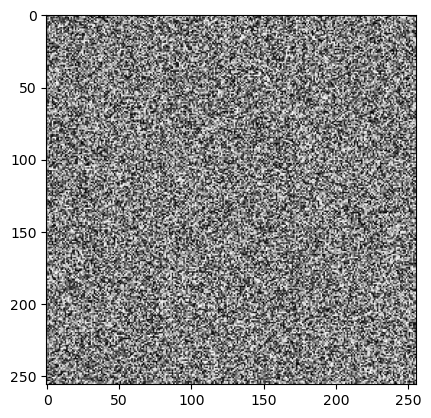

In [2]:
#Image is simply a 2D numpy array where each value represent a pixel.abs

#most common data type for image is unsiged 8-bit, covering values from 0 to 255 for every pixel 

random_image = np.random.randint(0,255, (256,256))    #random array 
plt.imshow(random_image, cmap='gray')        #Here 255 is represented as "White" and 0 as "Black"  


Text(0.5, 0, 'Intensity')

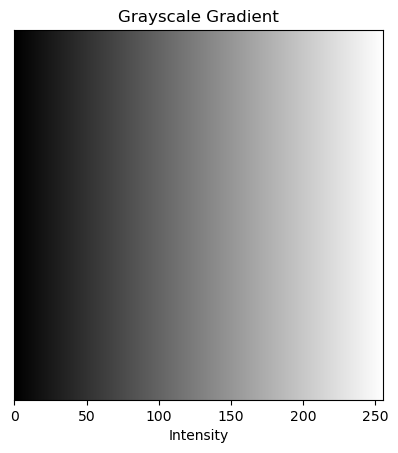

In [3]:
x = np.arange(0,256)   
y = np.ones((256,1)) 

gradient_im = x*y;     #creates a 256x256 image 

plt.imshow(gradient_im, cmap='gray')
plt.title('Grayscale Gradient')

ax=plt.gca(); ax.yaxis.set_ticks([]);   #remove the y-axis ticks and label
ax.xaxis.set_label_text('Intensity')

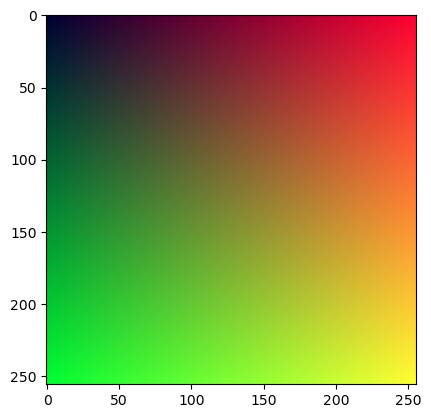

In [4]:
#Color images are 3 grayscale images stacked together - representing three channel (Red, Green, Blue) 

color_im = np.zeros((256,256,3), dtype=np.uint8) 
color_im[:,:,0] = gradient_im    #Red
color_im[:,:,1] = gradient_im.T  #Green 

blue_value = 50    #Change this and see the color changes
color_im[:,:,2] = np.ones((256,256), dtype=np.uint8) * blue_value   #Blue

plt.imshow(color_im)



In [5]:
#Reading an image:

p1 = plt.imread('images/parrot_rosellaMacaws_couple.jpg')

p1.shape   #It's a numpy array of 1256x1920 pixels. With 3 channels (R,G,B)

print(p1.dtype)   #np.uint8   - 8-bit Unsigned Int  
print(p1.max())   #255 
print(p1.min())   #0  



uint8
255
0


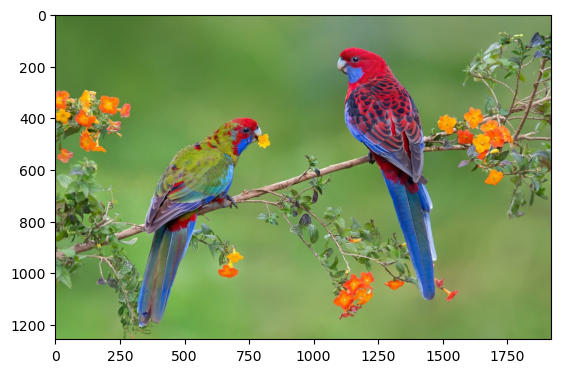

In [6]:
plt.imshow(p1)

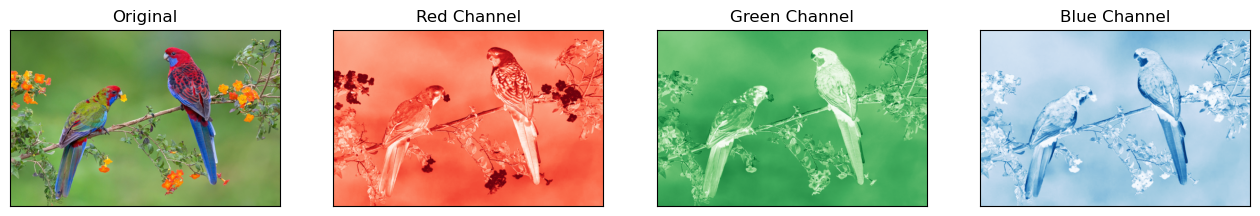

In [7]:
#Displaying R,G,B channels:

fig,ax = plt.subplots(1,4)
fig.set_size_inches(16,4) 

ax[0].imshow(p1)
ax[0].set_title('Original')
ax[0].xaxis.set_ticks([]); ax[0].yaxis.set_ticks([]);   #Removing ticks 

ax[1].imshow(p1[:,:,0], cmap='Reds')    #0
ax[1].set_title('Red Channel')
ax[1].xaxis.set_ticks([]); ax[1].yaxis.set_ticks([]);   

ax[2].imshow(p1[:,:,1], cmap='Greens')
ax[2].set_title('Green Channel')
ax[2].xaxis.set_ticks([]); ax[2].yaxis.set_ticks([]);

ax[3].imshow(p1[:,:,2], cmap='Blues')
ax[3].set_title('Blue Channel')
ax[3].xaxis.set_ticks([]); ax[3].yaxis.set_ticks([]);


Text(0.5, 1.0, 'Manually Converted Grayscale')

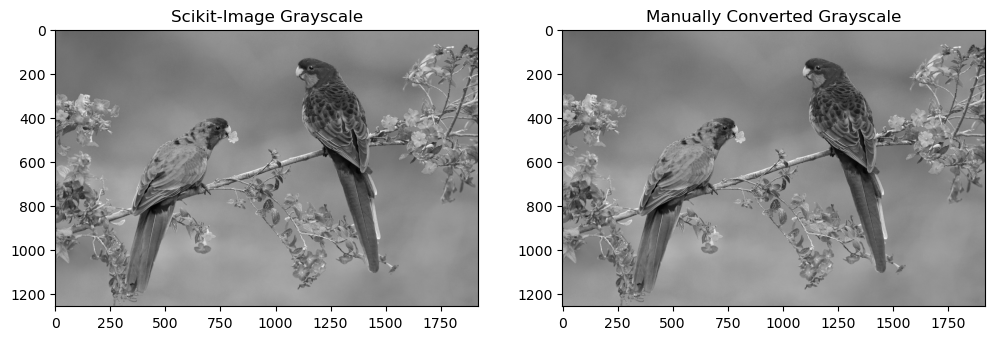

In [8]:
#Grayscale:

pg = ski.color.rgb2gray(p1)   #convert Color image to Grayscale image 
pg = (pg*256).astype('uint8')   #rgb2gray converts the data type to float (0.0...1.0). We are converting the image back to uint8 (0...255)

#This converts Color images to Grayscale by taking:  0.2126 * R_chanel + 0.7152 * Green_channel + 0.0722 * Blue_Channel

#Manually converting the color image to Grayscale:
pg_manual = 0.2126 * p1[:,:,0] + 0.7152 * p1[:,:,1] + 0.0722 * p1[:,:,2]    

fig,ax = plt.subplots(1,2) 
fig.set_size_inches(12,5)

ax[0].imshow(pg, cmap='gray')
ax[0].set_title('Scikit-Image Grayscale')

ax[1].imshow(pg_manual, cmap='gray')
ax[1].set_title('Manually Converted Grayscale')

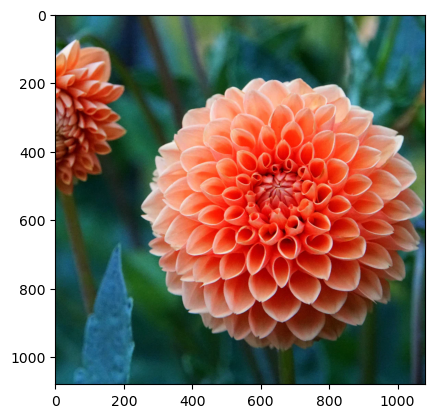

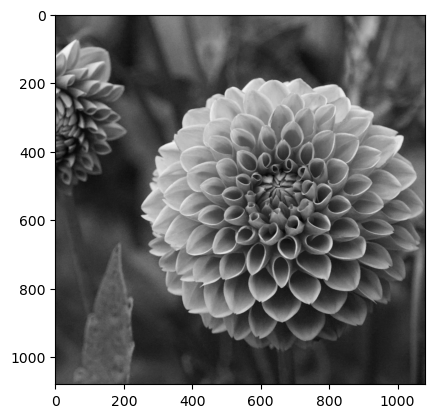

In [9]:
#Thresholding - Separating foreground from background.
dahlia = plt.imread('images/flower_dahlia_orange.jpg')
plt.imshow(dahlia)

#converts to grayscale:
dg = ski.color.rgb2gray(dahlia)      #we are keeping dtype as float 

plt.figure(); 
plt.imshow(dg, cmap='gray')



Max value: 0.987081568627451, Min value: 0.024166666666666666


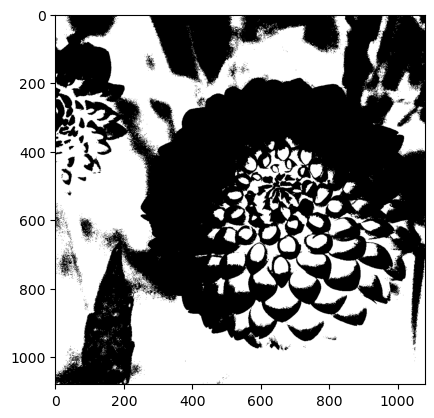

In [10]:
#Thresholding Contd: 

print(f'Max value: {dg.max()}, Min value: {dg.min()}')         #dtype is float. 0.0 represents Black, 1.0 represent White 

threshold = 0.3
dg_threshold = dg < threshold    #Setting all pixels <threshold to 1 (White), everything else to 0 (Black)

plt.imshow(dg_threshold, cmap='gray')

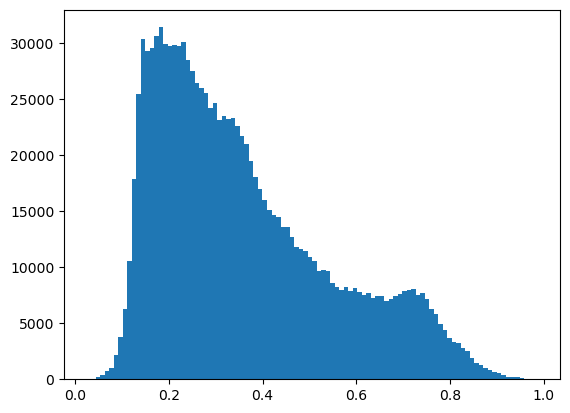

In [11]:
#Trying to find the best threshold:

#plotting the histogram (total counts of pixels with every value from 0 to 1)
plt.hist(dg.flatten(), bins=100);          

#Looking at histogram, there is no obvious point to threshold on. We just have to select any point after the main peak. Maybe anything >0.4 



0.4285156977634804


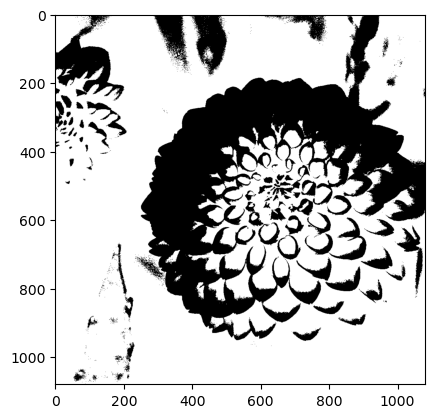

In [12]:
#Otsu thresholding:  (Refer: https://en.wikipedia.org/wiki/Otsu's_method) 

otsu_threshold = ski.filters.threshold_otsu(dg); 
print(otsu_threshold) 

plt.imshow(dg < otsu_threshold, cmap='gray')

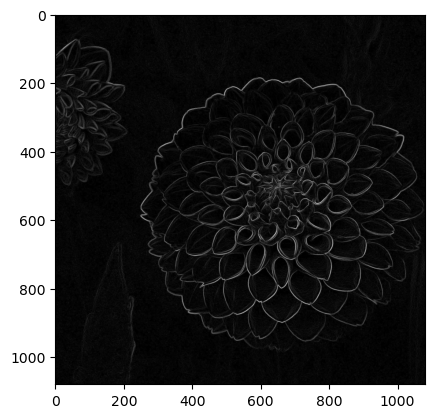

In [13]:
#Edge Detection:  

#Sobel (refer: https://en.wikipedia.org/wiki/Sobel_operator) 

dg_sobel = ski.filters.sobel(dg) 
plt.imshow(dg_sobel, cmap='gray') 


0.08381933990675344


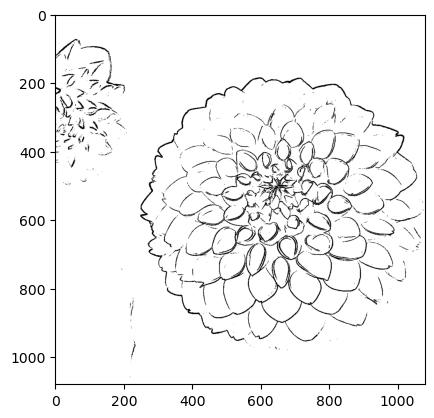

In [14]:
#Now applying otsu thresholding: 

otsu_threshold_sobel = ski.filters.threshold_otsu(dg_sobel); 
print(otsu_threshold_sobel) 

plt.imshow(dg_sobel < otsu_threshold_sobel, cmap='gray')

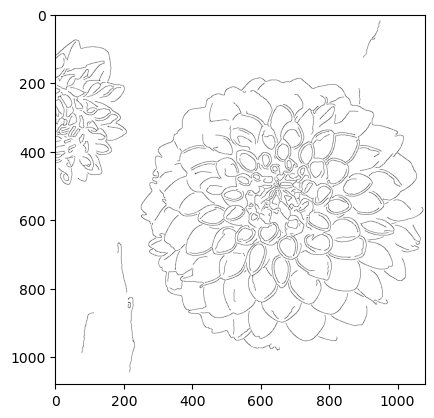

In [15]:
#Canny Edge Detection (Refer: https://en.wikipedia.org/wiki/Canny_edge_detector) 

#It automatically does edge detection and thresholding

dg_canny = ski.feature.canny(dg, sigma=2.2) 
plt.imshow(dg_canny, cmap='gray_r')